# 1. Intro

## i. To get started, please write 5 examples of the application of ML methods in life. What is the benefit of using machine learning methods in each of your examples? 

a. classification - распознание мошеннических операций для их предотвращения 

b. regression - вероятность дождя исходя из входных данных (облачность, ветер, направление ветра и т. д.) - прогноз погоды

c. clustering - рекомендательные системы группируют пользователей по признакам (время на сайте, покупки, оценки, история просмотров), но мы не можем знать заранее какие могут вообще быть типы пользователей 

d. association - пользователям, которым нравится исполнитель A, также часто нравится исполнитель B, поэтому его можно добавить в daily playlist 

e. dimesionality reduction (or generalization) - компьютерное зрение - нужно выделить и анализировать только важные пиксели картинки, чтобы определить, что товар на производстве с камерой бракован 

## ii. Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided.

1 - regression

2 - classification

3 - classification, regression

4 - classification

5 - clustering

6 - dimensionality reduction, classification

7 - clustering, association

8 - dimensionality reduction, association 

9 - clustering

10 - classification 

## iii. Think about what the difference is between multiclass and multilabel.

multiclass - много классов, объект не может принадлежать к нескольким одновременно 

multilabel - объект может иметь много меток одновременно 

## iv. Is an example case with house prices from the theory a classification of a regression problem? Is it possible to reduce the regression problem to classification?

это regression problem 

но мы можем выбрать в качестве target категорию стоимости (ниже среднего, средняя, выше среднего) исходя из категории дома (например, дом в центре + большая площадь = выше среднего) и тогда это будет classification

# 2. Introduction to Data Analysis

## i

In [1]:
%pip install statsmodels

     ---------------------------------------- 9.6/9.6 MB 888.0 kB/s eta 0:00:00
     ------------------------------------ 233.3/233.3 kB 892.2 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
import pandas as pd
import numpy as np 
import sklearn 
import lightgbm 
import scipy 
import statsmodels 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

## ii

In [115]:
df = pd.read_json('data/train.json')
df.shape

(49352, 15)

## iii

49352 строк и 15 столбцов

## iv

In [116]:
df.columns.to_list()

['bathrooms',
 'bedrooms',
 'building_id',
 'created',
 'description',
 'display_address',
 'features',
 'latitude',
 'listing_id',
 'longitude',
 'manager_id',
 'photos',
 'price',
 'street_address',
 'interest_level']

таргет - колонка price 

## v

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [118]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [119]:
df[['bathrooms', 'bedrooms', 'price']].corr()

,bathrooms,bedrooms,price
bathrooms,1.000000,0.533446,0.069661
bedrooms,0.533446,1.000000,0.051788
price,0.069661,0.051788,1.000000


корелляция ванных комнат, спален и цены

в целом, корелляция не такая сильная, потому что спальни и ванны не сильно влияют на цену жилья

## vi

In [120]:
df['interest_level']

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 49352, dtype: object

создала новый датафрейм только с интересующими нас колонками

In [121]:
new_df = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]
new_df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


# 3. Statistical Data Analysis

## iii

### a

Text(0.5, 1.0, 'price histogram')

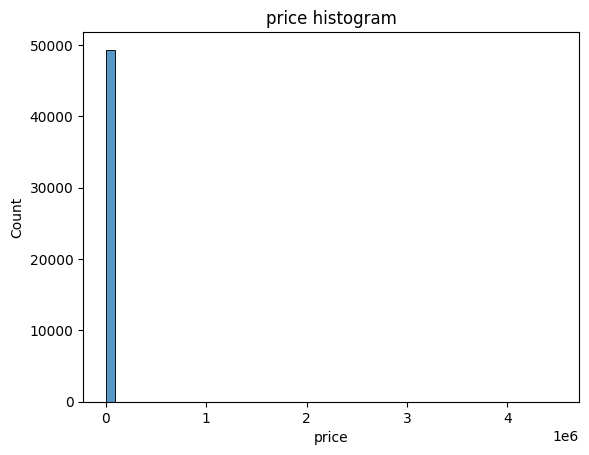

In [122]:
sns.histplot(new_df, x='price', bins=50)
plt.title('price histogram')

нет, по гистограмме ничего не понятно. по оси x seaborn "свернул" , поэтому получиломь что большая часть жилья стоит до 1 млн

### b

<Axes: xlabel='price'>

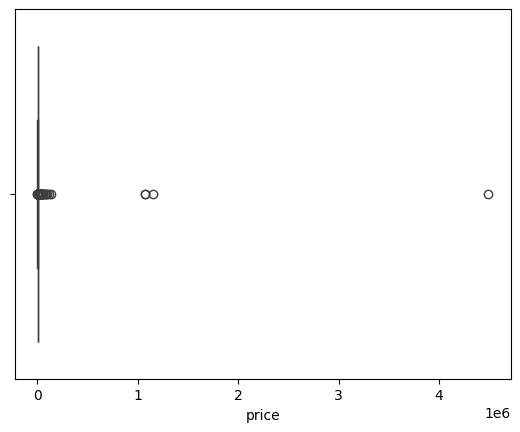

In [123]:
sns.boxplot(data=new_df, x='price')

да, есть немного выброов, но результат по стоимости идентичен с гистограммой, все еще не видно ничего кроме выбросов и вывода из предыдущего подпункта 

### c

In [124]:
low = new_df['price'].quantile(0.01)
high = new_df['price'].quantile(0.99)

In [125]:
new_df.drop(new_df[(new_df['price'] >= high) | (new_df['price'] <= low)].index, axis=0, inplace=True)

C:\Users\Liza\AppData\Local\Temp\ipykernel_26384\2305395549.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.drop(new_df[(new_df['price'] >= high) | (new_df['price'] <= low)].index, axis=0, inplace=True)


### d

Text(0.5, 1.0, 'new price histogram')

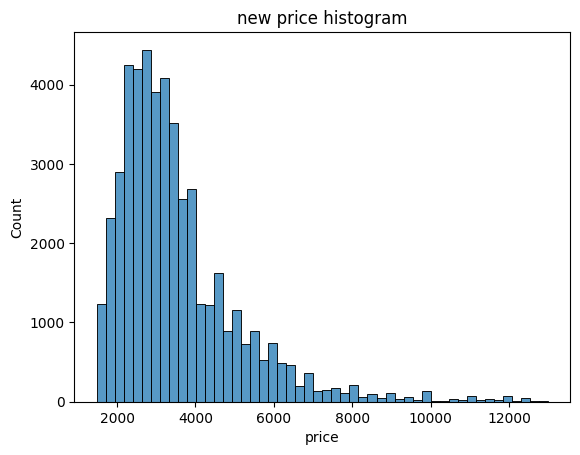

In [126]:
sns.histplot(new_df, x='price', bins=50)
plt.title('new price histogram')

## iv

### a - category type

### b

In [127]:
new_df['interest_level']

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48343, dtype: object

In [128]:
new_df['interest_level'].value_counts()

interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64

### c

In [129]:
new_df['interest_level'] = df['interest_level'].replace(['low', 'medium', 'high'], [0, 1, 2])
new_df['interest_level'].value_counts()

C:\Users\Liza\AppData\Local\Temp\ipykernel_26384\3786161351.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df['interest_level'] = df['interest_level'].replace(['low', 'medium', 'high'], [0, 1, 2])
C:\Users\Liza\AppData\Local\Temp\ipykernel_26384\3786161351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['interest_level'] = df['interest_level'].replace(['low', 'medium', 'high'], [0, 1, 2])


interest_level
0    33672
1    11114
2     3557
Name: count, dtype: int64

### d

<Axes: xlabel='bathrooms', ylabel='Count'>

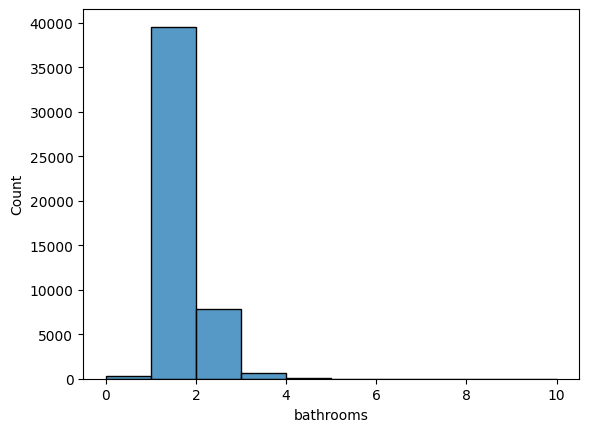

In [130]:
sns.histplot(data=new_df, x='bathrooms', bins=10)

<Axes: xlabel='bedrooms', ylabel='Count'>

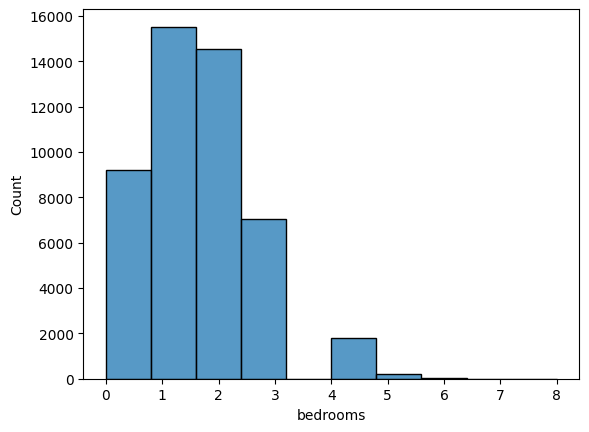

In [131]:
sns.histplot(data=new_df, x='bedrooms', bins=10)

да, из-за удаления выделяющих данных в предыдущих пунктах уже стало понятнее распределение цен. выбросов нет

## v

### a

In [132]:
corr_matrix = new_df[['bathrooms', 'bedrooms', 'interest_level', 'price']].corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


<Axes: >

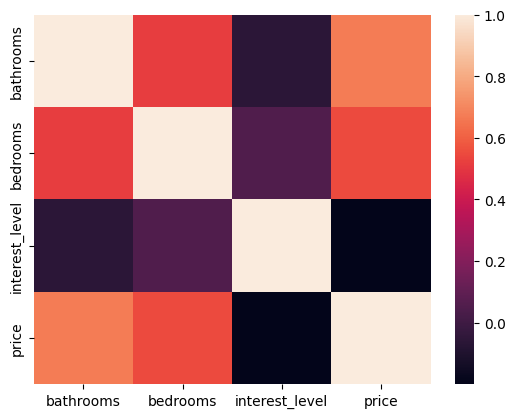

In [133]:
sns.heatmap(data=corr_matrix)

да, самая высокая корреляция наблюдается между price и bathrooms, а также между price и bedrooms

### b

<Axes: xlabel='price', ylabel='bathrooms'>

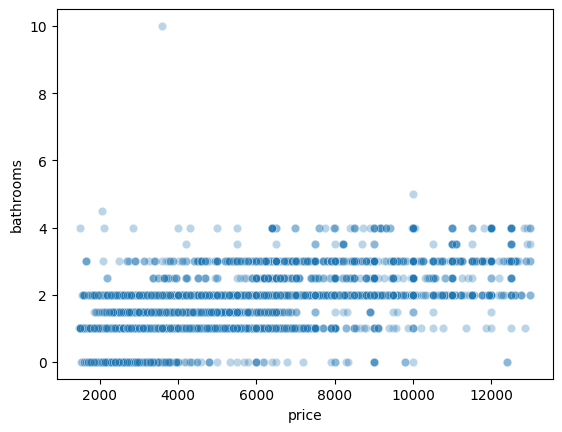

In [134]:
sns.scatterplot(data=new_df, x='price', y='bathrooms', alpha=0.3)

<Axes: xlabel='price', ylabel='bedrooms'>

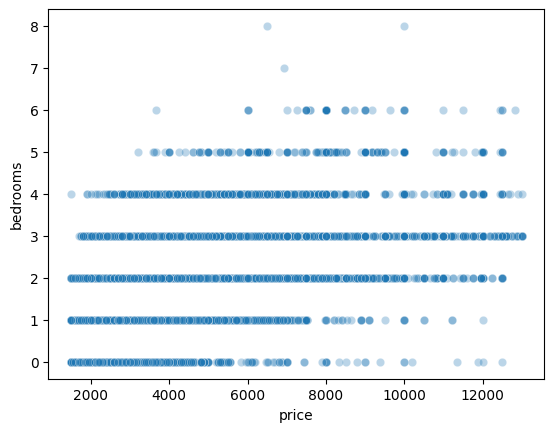

In [135]:
sns.scatterplot(data=new_df, x='price', y='bedrooms', alpha=0.3)

<Axes: xlabel='price', ylabel='interest_level'>

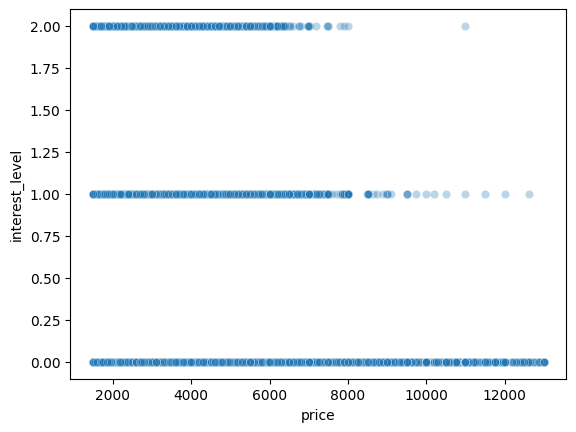

In [136]:
sns.scatterplot(data=new_df, x='price', y='interest_level', alpha=0.3)

# 4. Creating Features

## i

In [137]:
new_df['bathrooms_squared'] = new_df['bathrooms'].apply(lambda x: x ** 2)
new_df['bedrooms_squared'] = new_df['bedrooms'].apply(lambda x: x ** 2)
new_df['interest_level_squared'] = new_df['interest_level'].apply(lambda x: x ** 2)

C:\Users\Liza\AppData\Local\Temp\ipykernel_26384\406574783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['bathrooms_squared'] = new_df['bathrooms'].apply(lambda x: x ** 2)
C:\Users\Liza\AppData\Local\Temp\ipykernel_26384\406574783.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['bedrooms_squared'] = new_df['bedrooms'].apply(lambda x: x ** 2)
C:\Users\Liza\AppData\Local\Temp\ipykernel_26384\406574783.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

In [138]:
new_df[['bathrooms', 'bedrooms', 'interest_level', 'price', 'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared']].corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


нет, корелляция не увеличилась

## iv

In [139]:
y, X = new_df['price'], new_df[['bathrooms', 'bedrooms']]

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

## v

In [166]:
poly = PolynomialFeatures(degree=10)

## vi

In [167]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 5. Model training

## i

In [144]:
result_mae = pd.DataFrame(columns=['model', 'train', 'test'])
result_rmse = pd.DataFrame(columns=['model', 'train', 'test'])
result_mae

,model,train,test


## ii. Linear Regression

In [145]:
linreg = LinearRegression()

In [146]:
linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_test_pred = linreg.predict(X_test)
y_train_pred = linreg.predict(X_train)

In [148]:
mae_train = mean_absolute_error(y_true=y_train, y_pred=y_train_pred)
mae_test = mean_absolute_error(y_true=y_test, y_pred=y_test_pred)
rmse_train = root_mean_squared_error(y_true=y_train, y_pred=y_train_pred)
rmse_test = root_mean_squared_error(y_true=y_test, y_pred=y_test_pred)

In [149]:
result_mae.loc[0, 'model'] = 'linreg'
result_mae.loc[0, 'train'] = mae_train
result_mae.loc[0, 'test'] = mae_test

result_rmse.loc[0, 'model'] = 'linreg'
result_rmse.loc[0, 'train'] = rmse_train
result_rmse.loc[0, 'test'] = rmse_test
result_mae

,model,train,test
0,linreg,781.888942,782.139448


In [150]:
result_rmse

,model,train,test
0,linreg,1112.93291,1124.444956


## iii. Decision Tree

In [151]:
tree = DecisionTreeRegressor(random_state=21)

In [152]:
tree.fit(X=X_train, y=y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [153]:
y_test_pred = tree.predict(X_test)
y_train_pred = tree.predict(X_train)

In [154]:
mae_train = mean_absolute_error(y_true=y_train, y_pred=y_train_pred)
mae_test = mean_absolute_error(y_true=y_test, y_pred=y_test_pred)
rmse_train = root_mean_squared_error(y_true=y_train, y_pred=y_train_pred)
rmse_test = root_mean_squared_error(y_true=y_test, y_pred=y_test_pred)

In [155]:
result_mae.loc[1, 'model'] = 'tree'
result_mae.loc[1, 'train'] = mae_train
result_mae.loc[1, 'test'] = mae_test

result_rmse.loc[1, 'model'] = 'tree'
result_rmse.loc[1, 'train'] = rmse_train
result_rmse.loc[1, 'test'] = rmse_test
result_mae

,model,train,test
0,linreg,781.888942,782.139448
1,tree,754.013281,755.163063


In [156]:
result_rmse

,model,train,test
0,linreg,1112.93291,1124.444956
1,tree,1069.623883,1078.556925


## iv. Naive Models

In [157]:
mean_price = y_train.mean()
median_price = y_train.median()

In [158]:
y_train_pred_mean = np.full(len(y_train), mean_price)
y_test_pred_mean = np.full(len(y_test), mean_price)

y_train_pred_median = np.full(len(y_train), median_price)
y_test_pred_median = np.full(len(y_test), median_price)

In [159]:
mae_train = mean_absolute_error(y_true=y_train, y_pred=y_train_pred_mean)
mae_test = mean_absolute_error(y_true=y_test, y_pred=y_test_pred_mean)
rmse_train = root_mean_squared_error(y_true=y_train, y_pred=y_train_pred_mean)
rmse_test = root_mean_squared_error(y_true=y_test, y_pred=y_test_pred_mean)

In [160]:
result_mae.loc[2, 'model'] = 'naive_mean'
result_mae.loc[2, 'train'] = mae_train
result_mae.loc[2, 'test'] = mae_test

result_rmse.loc[2, 'model'] = 'naive_mean'
result_rmse.loc[2, 'train'] = rmse_train
result_rmse.loc[2, 'test'] = rmse_test

In [161]:
result_rmse

,model,train,test
0,linreg,1112.93291,1124.444956
1,tree,1069.623883,1078.556925
2,naive_mean,1581.175846,1598.835357


In [162]:
mae_train = mean_absolute_error(y_true=y_train, y_pred=y_train_pred_median)
mae_test = mean_absolute_error(y_true=y_test, y_pred=y_test_pred_median)
rmse_train = root_mean_squared_error(y_true=y_train, y_pred=y_train_pred_median)
rmse_test = root_mean_squared_error(y_true=y_test, y_pred=y_test_pred_median)

In [163]:
result_mae.loc[3, 'model'] = 'naive_median'
result_mae.loc[3, 'train'] = mae_train
result_mae.loc[3, 'test'] = mae_test

result_rmse.loc[3, 'model'] = 'naive_median'
result_rmse.loc[3, 'train'] = rmse_train
result_rmse.loc[3, 'test'] = rmse_test

## v. Results

In [164]:
result_mae

,model,train,test
0,linreg,781.888942,782.139448
1,tree,754.013281,755.163063
2,naive_mean,1133.206995,1138.576075
3,naive_median,1081.969302,1082.975509


In [165]:
result_rmse

,model,train,test
0,linreg,1112.93291,1124.444956
1,tree,1069.623883,1078.556925
2,naive_mean,1581.175846,1598.835357
3,naive_median,1627.578464,1644.081484


лучшая модель - Decision Tree, но ее значение ошибок все еще довольно высокое